<a href="https://colab.research.google.com/github/Prathamesh-exe/AI-ML-Colabs-and-Gists/blob/main/LLM_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Building & Training a Modern LLM
## From scratch — RMSNorm, SwiGLU, RoPE, GQA

---



## Section 0: Setup

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import math
import time
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
# macbook : "mps"
print(f"Using device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


## Section 0.1: Download & Prepare Dataset

In [ ]:
import os
import urllib.request

# Download a small subset of TinyStories for development
DATA_URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/TinyStories-train.txt"
DATA_FILE = "tinystories.txt"

MAX_BYTES = 20 * 1024 * 1024  # 20 MB

if not os.path.exists(DATA_FILE):
    print("Downloading TinyStories (first 20 MB)...")

    response = urllib.request.urlopen(DATA_URL)

    with open(DATA_FILE, "wb") as f:
        downloaded = 0

        while downloaded < MAX_BYTES:
            chunk = response.read(
                min(1024 * 1024, MAX_BYTES - downloaded)
            )

            if not chunk:
                break

            f.write(chunk)
            downloaded += len(chunk)

    print(f"Downloaded: {downloaded / 1024 / 1024:.2f} MB")
else:
    print(f"{DATA_FILE} already exists. Skipping download.")

# Load dataset
with open(DATA_FILE, "r", encoding="utf-8") as f:
    text = f.read()

print(f"Total characters: {len(text):,}")
print(f"First 200 characters:\n{text[:200]}")

Downloaded: 20.00 MB
Total characters: 20,956,665
First 200 characters:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on


# Byte Pair Encoding tokenization

---




In [ ]:
from tokenizers import Tokenizer
from tokenizers.models import BPE
from tokenizers.trainers import BpeTrainer
from tokenizers.pre_tokenizers import ByteLevel

# Train BPE tokenizer
tokenizer = Tokenizer(
    BPE(unk_token="<UNK>")
)

# Byte-level preprocessing
tokenizer.pre_tokenizer = ByteLevel()

# Special tokens
special_tokens = [
    "<UNK>",
    "<PAD>",
    "<BOS>",
    "<EOS>",
]

# BPE trainer
trainer = BpeTrainer(
    vocab_size=4096,
    min_frequency=2,
    special_tokens=special_tokens,
)

# Train tokenizer on TinyStories
print("Training BPE tokenizer...")

tokenizer.train(
    ["tinystories.txt"],
    trainer
)

print("BPE tokenizer training complete.")

# Vocabulary
vocab_size = tokenizer.get_vocab_size()

print(f"\nVocabulary size: {vocab_size}")

# Encode / Decode helpers
def encode(s):
    return tokenizer.encode(s).ids


def decode(ids):
    return tokenizer.decode(ids)


# Test tokenizer
examples = [
    "Hello",
    "Hello world!",
    "Once upon a time",
    "The little girl was playing.",
]

print("\nTokenizer examples:")

for example in examples:
    encoding = tokenizer.encode(example)

    print("\n--------------------------------")
    print(f"Text:    {example}")
    print(f"Tokens:  {encoding.tokens}")
    print(f"IDs:     {encoding.ids}")
    print(f"Decoded: {decode(encoding.ids)}")


# Save tokenizer
tokenizer.save("tokenizer.json")

print("\nTokenizer saved to tokenizer.json")

Training BPE tokenizer...
BPE tokenizer training complete.

Vocabulary size: 4096

Tokenizer examples:

--------------------------------
Text:    Hello
Tokens:  ['ĠHe', 'llo']
IDs:     [164, 1852]
Decoded: ĠHe llo

--------------------------------
Text:    Hello world!
Tokens:  ['ĠHe', 'llo', 'Ġworld', '!']
IDs:     [164, 1852, 1084, 4]
Decoded: ĠHe llo Ġworld !

--------------------------------
Text:    Once upon a time
Tokens:  ['ĠOnce', 'Ġupon', 'Ġa', 'Ġtime']
IDs:     [287, 299, 108, 254]
Decoded: ĠOnce Ġupon Ġa Ġtime

--------------------------------
Text:    The little girl was playing.
Tokens:  ['ĠThe', 'Ġlittle', 'Ġgirl', 'Ġwas', 'Ġplaying', '.']
IDs:     [136, 257, 305, 132, 459, 15]
Decoded: ĠThe Ġlittle Ġgirl Ġwas Ġplaying .

Tokenizer saved to tokenizer.json


In [ ]:
# Train/validation split (90/10)
split_idx = int(0.9 * len(text))

train_text = text[:split_idx]
val_text = text[split_idx:]

# Encode using BPE tokenizer
train_data = torch.tensor(
    encode(train_text),
    dtype=torch.long
)

val_data = torch.tensor(
    encode(val_text),
    dtype=torch.long
)

print(f"Training tokens:   {len(train_data):,}")
print(f"Validation tokens: {len(val_data):,}")

print(f"\nTraining characters:   {len(train_text):,}")
print(f"Validation characters: {len(val_text):,}")

Training tokens:   4,820,622
Validation tokens: 531,038

Training characters:   18,860,998
Validation characters: 2,095,667


In [ ]:
# Batching: grab random chunks of BPE tokens
def get_batch(split, batch_size, context_length):
    d = train_data if split == "train" else val_data

    # Random starting positions
    ix = torch.randint(
        len(d) - context_length,
        (batch_size,)
    )

    # Input sequences
    x = torch.stack([
        d[i:i + context_length]
        for i in ix
    ])

    # Target sequences (shifted by one token)
    y = torch.stack([
        d[i + 1:i + context_length + 1]
        for i in ix
    ])

    return x.to(device), y.to(device)


# Quick test
xb, yb = get_batch(
    "train",
    batch_size=4,
    context_length=8
)

print(f"Input shape:  {xb.shape}  (batch_size x context_length)")
print(f"Target shape: {yb.shape}")

print("\nExample (first sequence):")

print(f"  Input IDs:  {xb[0].tolist()}")
print(f"  Target IDs: {yb[0].tolist()}")

print(f"\n  Input:  {decode(xb[0].tolist())!r}")
print(f"  Target: {decode(yb[0].tolist())!r}")

print("\nTarget is the input shifted by 1 BPE token.")

Input shape:  torch.Size([4, 8])  (batch_size x context_length)
Target shape: torch.Size([4, 8])

Example (first sequence):
  Input IDs:  [839, 114, 2168, 153, 409, 275, 95, 2224]
  Target IDs: [114, 2168, 153, 409, 275, 95, 2224, 114]

  Input:  'Ġtruck Ġand Ġdrive Ġit Ġtogether ." Ċ Tom'
  Target: 'Ġand Ġdrive Ġit Ġtogether ." Ċ Tom Ġand'

Target is the input shifted by 1 BPE token.


---
# Section 1: RMSNorm


In [ ]:
class RMSNorm(nn.Module):
    """
    Root Mean Square Layer Normalization.

    Simpler than LayerNorm:
    - No mean subtraction
    - No bias/shift parameter
    - Just: x / RMS(x) * learnable_scale
    """
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        rms = torch.sqrt(x.pow(2).mean(dim=-1, keepdim=True) + self.eps)
        return (x / rms) * self.weight

# Dropout randomly zeroes some values during training,
# forcing the model to not rely on any single feature.
# This prevents memorization (overfitting).
DROPOUT = 0.2


# --- Demo ---
demo_x = torch.randn(2, 4, 8)
norm = RMSNorm(8)
demo_out = norm(demo_x)

print("RMSNorm demo:")
print(f"  Input  - mean: {demo_x.mean():.3f}, std: {demo_x.std():.3f}")
print(f"  Output - mean: {demo_out.mean():.3f}, std: {demo_out.std():.3f}")
print(f"  Input range:  [{demo_x.min():.3f}, {demo_x.max():.3f}]")
print(f"  Output range: [{demo_out.min():.3f}, {demo_out.max():.3f}]")
print(f"\n  Parameters: just a scale vector of size {norm.weight.shape}")

RMSNorm demo:
  Input  - mean: -0.235, std: 1.046
  Output - mean: -0.243, std: 0.978
  Input range:  [-3.009, 2.117]
  Output range: [-2.324, 2.102]

  Parameters: just a scale vector of size torch.Size([8])


---
# Section 2: Rotary Positional Embeddings (RoPE)


In [ ]:
# Rotary Positional Embeddings (RoPE)
def precompute_rope_freqs(
    head_dim,
    max_seq_len,
    base=10000.0,
    device=None,
):
    """
    Precompute cosine and sine tables for RoPE.

    head_dim:
        Dimension of each attention head.

    max_seq_len:
        Maximum context length supported by the model.

    base:
        Controls the range of rotation frequencies.

    Returns:
        cos: [max_seq_len, head_dim // 2]
        sin: [max_seq_len, head_dim // 2]
    """

    # Frequencies for each pair of dimensions
    freqs = 1.0 / (
        base ** (
            torch.arange(
                0,
                head_dim,
                2,
                dtype=torch.float32,
                device=device,
            ) / head_dim
        )
    )

    # Position indices: 0, 1, 2, ..., max_seq_len - 1
    positions = torch.arange(
        max_seq_len,
        dtype=torch.float32,
        device=device,
    )

    # [max_seq_len, head_dim // 2]
    angles = torch.outer(positions, freqs)

    # Precompute sin/cos so we don't calculate them every forward pass
    cos = torch.cos(angles)
    sin = torch.sin(angles)

    return cos, sin


def apply_rope(x, cos, sin):
    """
    Apply Rotary Positional Embeddings to query/key tensors.

    x:
        [batch, n_heads, seq_len, head_dim]

    cos:
        [max_seq_len, head_dim // 2]

    sin:
        [max_seq_len, head_dim // 2]
    """

    seq_len = x.shape[2]

    # Select only the positions used by this sequence
    cos = cos[:seq_len]
    sin = sin[:seq_len]

    # Add batch and head dimensions
    #
    # [seq_len, head_dim // 2]
    #        ↓
    # [1, 1, seq_len, head_dim // 2]
    #
    cos = cos.unsqueeze(0).unsqueeze(0)
    sin = sin.unsqueeze(0).unsqueeze(0)

    # Split pairs of dimensions
    #
    # x[..., 0], x[..., 2], x[..., 4], ...
    x1 = x[..., ::2]

    # x[..., 1], x[..., 3], x[..., 5], ...
    x2 = x[..., 1::2]

    # Apply 2D rotation to every pair
    out1 = x1 * cos - x2 * sin
    out2 = x1 * sin + x2 * cos

    # Interleave the rotated dimensions again
    #
    # [out1, out2]
    #      ↓
    # [dim0, dim1, dim2, dim3, ...]
    return torch.stack(
        [out1, out2],
        dim=-1
    ).flatten(-2)

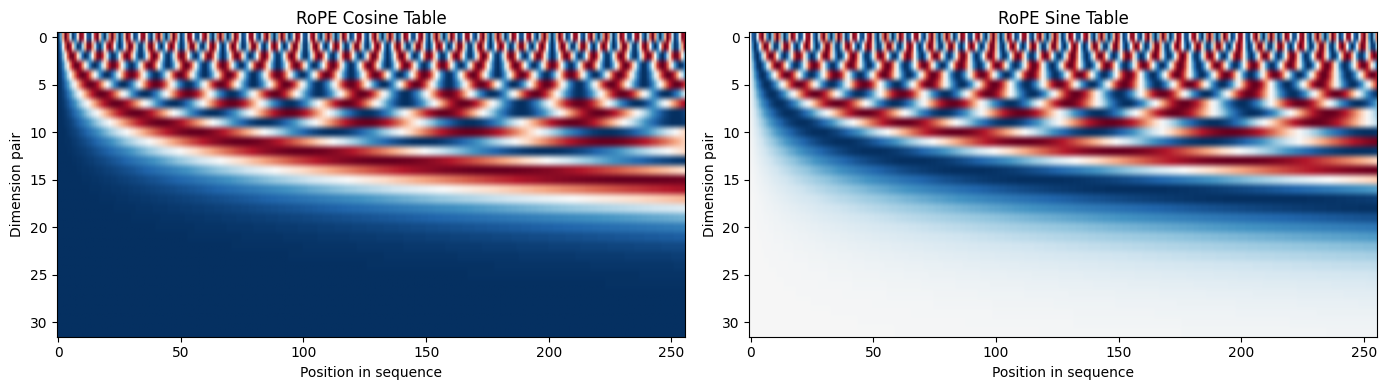

RoPE visualization:
  Head dimension: 64
  Sequence length: 256
  Number of dimension pairs: 32

Lower dimension pairs -> higher frequency -> faster rotation
Higher dimension pairs -> lower frequency -> slower rotation


In [ ]:
# --------------------------------------------------
# Visualize RoPE rotation frequencies
# --------------------------------------------------

demo_head_dim = 64
demo_max_seq_len = 256

demo_cos, demo_sin = precompute_rope_freqs(
    head_dim=demo_head_dim,
    max_seq_len=demo_max_seq_len,
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Cosine table
axes[0].imshow(
    demo_cos.T.numpy(),
    aspect="auto",
    cmap="RdBu",
    vmin=-1,
    vmax=1,
)

axes[0].set_xlabel("Position in sequence")
axes[0].set_ylabel("Dimension pair")
axes[0].set_title("RoPE Cosine Table")

# Sine table
axes[1].imshow(
    demo_sin.T.numpy(),
    aspect="auto",
    cmap="RdBu",
    vmin=-1,
    vmax=1,
)

axes[1].set_xlabel("Position in sequence")
axes[1].set_ylabel("Dimension pair")
axes[1].set_title("RoPE Sine Table")

plt.tight_layout()
plt.show()

print("RoPE visualization:")
print(
    f"  Head dimension: {demo_head_dim}"
)
print(
    f"  Sequence length: {demo_max_seq_len}"
)
print(
    f"  Number of dimension pairs: {demo_head_dim // 2}"
)

print(
    "\nLower dimension pairs -> higher frequency -> faster rotation"
)

print(
    "Higher dimension pairs -> lower frequency -> slower rotation"
)

---
# Section 3: Grouped Query Attention (GQA)

**What you know:** Multi-Head Attention — each head has its own Q, K, V.

**The upgrade:** GQA uses fewer K,V heads than Q heads. Groups of query heads *share* key-value pairs. Same quality, much less memory for the KV cache.

In [ ]:
# Grouped Query Attention (GQA)
def repeat_kv(x, n_rep):
    """
    Repeat Key/Value heads to match the number of Query heads.

    Input:
        x: [batch, n_kv_heads, seq_len, head_dim]

    Output:
        [batch, n_kv_heads * n_rep, seq_len, head_dim]

    Example:
        n_heads = 8
        n_kv_heads = 2

        Each KV head is shared by:
            8 / 2 = 4 query heads
    """

    if n_rep == 1:
        return x

    b, n_kv, seq, head_dim = x.shape

    return (
        x[:, :, None, :, :]
        .expand(b, n_kv, n_rep, seq, head_dim)
        .reshape(
            b,
            n_kv * n_rep,
            seq,
            head_dim,
        )
    )


class GroupedQueryAttention(nn.Module):
    """
    Grouped Query Attention (GQA) with RoPE.

    Query heads:
        n_heads

    Key/Value heads:
        n_kv_heads

    Multiple Query heads share the same Key/Value head.

    Example:
        n_heads = 8
        n_kv_heads = 2

        Query groups:

            Q0 Q1 Q2 Q3 → K0, V0
            Q4 Q5 Q6 Q7 → K1, V1
    """

    def __init__(self, d_model, n_heads, n_kv_heads):
        super().__init__()

        assert d_model % n_heads == 0
        assert n_heads % n_kv_heads == 0

        self.n_heads = n_heads
        self.n_kv_heads = n_kv_heads

        # Number of Query heads sharing each KV head
        self.n_rep = n_heads // n_kv_heads

        # Dimension of each attention head
        self.head_dim = d_model // n_heads

        # --------------------------------------------------
        # Q, K, V projections
        # --------------------------------------------------

        self.q_proj = nn.Linear(
            d_model,
            n_heads * self.head_dim,
            bias=False,
        )

        self.k_proj = nn.Linear(
            d_model,
            n_kv_heads * self.head_dim,
            bias=False,
        )

        self.v_proj = nn.Linear(
            d_model,
            n_kv_heads * self.head_dim,
            bias=False,
        )

        # Output projection
        self.o_proj = nn.Linear(
            n_heads * self.head_dim,
            d_model,
            bias=False,
        )

    def forward(self, x, rope_cos, rope_sin):

        # x:
        # [batch, seq_len, d_model]

        b, seq, _ = x.shape

        # 1. Create Query, Key, Value
        q = self.q_proj(x)
        k = self.k_proj(x)
        v = self.v_proj(x)

        # q:
        # [batch, seq, n_heads * head_dim]
        #
        # k/v:
        # [batch, seq, n_kv_heads * head_dim]

        # 2. Split into attention heads
        q = q.view(
            b,
            seq,
            self.n_heads,
            self.head_dim,
        ).transpose(1, 2)

        k = k.view(
            b,
            seq,
            self.n_kv_heads,
            self.head_dim,
        ).transpose(1, 2)

        v = v.view(
            b,
            seq,
            self.n_kv_heads,
            self.head_dim,
        ).transpose(1, 2)

        # Shapes:
        #
        # q = [batch, n_heads, seq, head_dim]
        # k = [batch, n_kv_heads, seq, head_dim]
        # v = [batch, n_kv_heads, seq, head_dim]

        # 3. Apply RoPE
        # RoPE is applied to Q and K.
        # V does NOT receive RoPE.

        q = apply_rope(
            q,
            rope_cos,
            rope_sin,
        )

        k = apply_rope(
            k,
            rope_cos,
            rope_sin,
        )

        # 4. Repeat KV heads
        k = repeat_kv(
            k,
            self.n_rep,
        )

        v = repeat_kv(
            v,
            self.n_rep,
        )

        # Now:
        #
        # q = [batch, n_heads, seq, head_dim]
        # k = [batch, n_heads, seq, head_dim]
        # v = [batch, n_heads, seq, head_dim]

        # 5. Scaled dot-product attention
        scale = 1.0 / math.sqrt(self.head_dim)

        scores = (
            q @ k.transpose(-2, -1)
        ) * scale

        # scores:
        #
        # [batch, n_heads, seq, seq]
        #
        # scores[b, h, i, j]
        # = how much token i attends to token j

        # 6. Causal mask
        # Prevent a token from seeing future tokens.
        #
        # Example:
        #
        #        token
        #        0  1  2  3
        #
        # token 0  ✓  ✗  ✗  ✗
        # token 1  ✓  ✓  ✗  ✗
        # token 2  ✓  ✓  ✓  ✗
        # token 3  ✓  ✓  ✓  ✓

        mask = torch.triu(
            torch.ones(
                seq,
                seq,
                device=x.device,
                dtype=torch.bool,
            ),
            diagonal=1,
        )

        scores = scores.masked_fill(
            mask,
            float("-inf"),
        )

        # 7. Convert scores to attention probabilities
        weights = F.softmax(
            scores,
            dim=-1,
        )

        # Dropout for regularization
        weights = F.dropout(
            weights,
            p=DROPOUT,
            training=self.training,
        )

        # 8. Weighted sum of Values
        out = weights @ v

        # out:
        # [batch, n_heads, seq, head_dim]

        # 9. Merge attention heads
        out = (
            out.transpose(1, 2)
            .contiguous()
            .view(b, seq, -1)
        )

        # [batch, seq, d_model]

        # 10. Output projection
        return self.o_proj(out)

In [ ]:
# Demo: GQA shapes and parameter savings

print("GQA Shape Demo:")
print("  Config: d_model=256, n_heads=8, n_kv_heads=2")
print("  -> head_dim = 256 / 8 = 32")
print("  -> 8 Query heads, 2 Key/Value heads")
print("  -> each KV head is shared by 4 Query heads")
print("  -> sequence length = 16 BPE tokens\n")


# --------------------------------------------------
# Create GQA module
# --------------------------------------------------

demo_gqa = GroupedQueryAttention(
    d_model=256,
    n_heads=8,
    n_kv_heads=2,
).to(device)


# --------------------------------------------------
# Create RoPE tables
# --------------------------------------------------

demo_cos, demo_sin = precompute_rope_freqs(
    head_dim=32,
    max_seq_len=128,
    device=device,
)


# --------------------------------------------------
# Dummy input
# --------------------------------------------------

# [batch_size, sequence_length, d_model]
#
# 2 sequences
# 16 BPE tokens per sequence
# 256-dimensional embeddings

demo_in = torch.randn(
    2,
    16,
    256,
    device=device,
)


# --------------------------------------------------
# Forward pass
# --------------------------------------------------

demo_out = demo_gqa(
    demo_in,
    demo_cos,
    demo_sin,
)


# --------------------------------------------------
# Shape results
# --------------------------------------------------

print(f"  Input:  {demo_in.shape}")
print(f"  Output: {demo_out.shape}")


# --------------------------------------------------
# Parameter calculation
# --------------------------------------------------

q_params = 256 * (8 * 32)

kv_params = (
    256 * (2 * 32) * 2
)

print(
    f"\n  Q projection params:  "
    f"{q_params:,}  (8 Query heads)"
)

print(
    f"  KV projection params: "
    f"{kv_params:,}  (2 KV heads)"
)

print(
    f"  KV cache savings: "
    f"{8 // 2}x smaller than standard MHA"
)

GQA Shape Demo:
  Config: d_model=256, n_heads=8, n_kv_heads=2
  -> head_dim = 256 / 8 = 32
  -> 8 Query heads, 2 Key/Value heads
  -> each KV head is shared by 4 Query heads
  -> sequence length = 16 BPE tokens

  Input:  torch.Size([2, 16, 256])
  Output: torch.Size([2, 16, 256])

  Q projection params:  65,536  (8 Query heads)
  KV projection params: 32,768  (2 KV heads)
  KV cache savings: 4x smaller than standard MHA


---
# Section 4: SwiGLU Feed-Forward Network



In [ ]:
class SwiGLU(nn.Module):
    """
    SwiGLU Feed-Forward Network.

    Input:
        x: [batch, seq_len, d_model]

    Two parallel projections:

        gate = SiLU(x @ W_gate)
        up   = x @ W_up

    The gate controls how much information from the
    up-projection should pass through.

        output = (gate * up) @ W_down

    SiLU(x) = x * sigmoid(x)
    """

    def __init__(self, d_model, hidden_dim):
        super().__init__()

        # Gate pathway
        self.w_gate = nn.Linear(
            d_model,
            hidden_dim,
            bias=False
        )

        # Information pathway
        self.w_up = nn.Linear(
            d_model,
            hidden_dim,
            bias=False
        )

        # Project back to model dimension
        self.w_down = nn.Linear(
            hidden_dim,
            d_model,
            bias=False
        )

    def forward(self, x):

        # x:
        # [batch, seq_len, d_model]

        # Gate pathway
        gate = F.silu(
            self.w_gate(x)
        )

        # Information pathway
        up = self.w_up(x)

        # Gated information
        x = gate * up

        # Project back to d_model
        x = self.w_down(x)

        # Dropout
        x = F.dropout(
            x,
            p=DROPOUT,
            training=self.training
        )

        return x

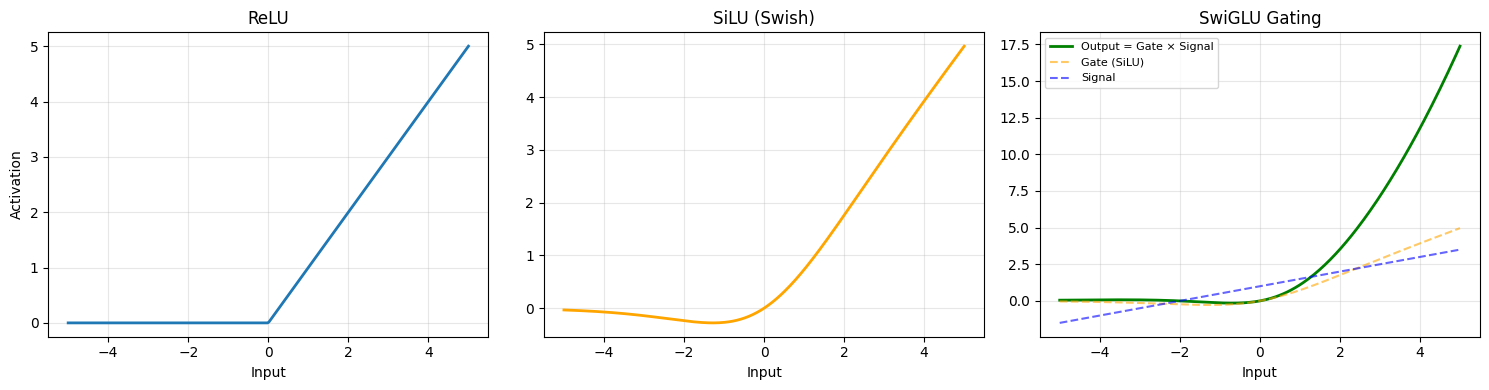

SwiGLU intuition:
  ReLU  : hard cutoff at x = 0
  SiLU  : smooth activation that keeps small negative information
  SwiGLU: learns to gate the signal instead of simply activating it


In [ ]:
# --------------------------------------------------
# Demo: ReLU vs SiLU vs SwiGLU
# --------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

x = torch.linspace(-5, 5, 300)

# --------------------------------------------------
# 1. ReLU
# --------------------------------------------------

relu = F.relu(x)

axes[0].plot(x, relu, linewidth=2)
axes[0].set_title("ReLU")
axes[0].set_xlabel("Input")
axes[0].set_ylabel("Activation")
axes[0].grid(alpha=0.3)

# --------------------------------------------------
# 2. SiLU / Swish
# --------------------------------------------------

silu = F.silu(x)

axes[1].plot(x, silu, linewidth=2, color="orange")
axes[1].set_title("SiLU (Swish)")
axes[1].set_xlabel("Input")
axes[1].grid(alpha=0.3)

# --------------------------------------------------
# 3. SwiGLU gating
# --------------------------------------------------

gate = silu                  # Gate pathway
signal = x * 0.5 + 1         # Information pathway
output = gate * signal       # Gated output

axes[2].plot(
    x,
    output,
    linewidth=2,
    color="green",
    label="Output = Gate × Signal",
)

axes[2].plot(
    x,
    gate,
    "--",
    color="orange",
    alpha=0.6,
    label="Gate (SiLU)",
)

axes[2].plot(
    x,
    signal,
    "--",
    color="blue",
    alpha=0.6,
    label="Signal",
)

axes[2].set_title("SwiGLU Gating")
axes[2].set_xlabel("Input")
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("SwiGLU intuition:")
print("  ReLU  : hard cutoff at x = 0")
print("  SiLU  : smooth activation that keeps small negative information")
print("  SwiGLU: learns to gate the signal instead of simply activating it")

---
# Section 5: Assemble the Full Model



In [ ]:
class TransformerBlock(nn.Module):
    """
    One Transformer block.

    Architecture:

        x
        │
        ├── RMSNorm
        │
        ├── GQA Attention
        │
        └── + Residual
             │
             x
             │
        ├── RMSNorm
        │
        ├── SwiGLU FFN
        │
        └── + Residual

    This is a Pre-Norm Transformer architecture.
    """

    def __init__(
        self,
        d_model,
        n_heads,
        n_kv_heads,
        ffn_hidden_dim,
    ):
        super().__init__()

        # Normalize before attention
        self.attn_norm = RMSNorm(d_model)

        # Grouped Query Attention + RoPE
        self.attention = GroupedQueryAttention(
            d_model=d_model,
            n_heads=n_heads,
            n_kv_heads=n_kv_heads,
        )

        # Normalize before FFN
        self.ffn_norm = RMSNorm(d_model)

        # SwiGLU feed-forward network
        self.ffn = SwiGLU(
            d_model=d_model,
            hidden_dim=ffn_hidden_dim,
        )

    def forward(self, x, rope_cos, rope_sin):

        # ----------------------------------------
        # 1. Pre-Norm → Attention → Residual
        # ----------------------------------------

        residual = x

        x = self.attn_norm(x)

        x = self.attention(
            x,
            rope_cos,
            rope_sin,
        )

        x = residual + x

        # ----------------------------------------
        # 2. Pre-Norm → SwiGLU → Residual
        # ----------------------------------------

        residual = x

        x = self.ffn_norm(x)

        x = self.ffn(x)

        x = residual + x

        return x

In [ ]:
class MiniLLM(nn.Module):
    """
    A small modern decoder-only language model.

    Architecture:
        BPE Token Embedding
            ↓
        Transformer Blocks
            ├── RMSNorm
            ├── GQA + RoPE
            ├── Residual
            ├── RMSNorm
            ├── SwiGLU
            └── Residual
            ↓
        Final RMSNorm
            ↓
        LM Head

    Training objective:
        Next BPE-token prediction
    """

    def __init__(
        self,
        vocab_size,
        d_model,
        n_layers,
        n_heads,
        n_kv_heads,
        ffn_hidden_dim,
        max_seq_len,
    ):
        super().__init__()

        self.d_model = d_model
        self.max_seq_len = max_seq_len

        # --------------------------------------------------
        # Token Embedding
        # --------------------------------------------------
        #
        # BPE token ID
        #       ↓
        # dense vector of size d_model
        #
        # Shape:
        # [vocab_size, d_model]
        #
        self.token_emb = nn.Embedding(
            vocab_size,
            d_model,
        )

        # --------------------------------------------------
        # Transformer Blocks
        # --------------------------------------------------

        self.layers = nn.ModuleList([
            TransformerBlock(
                d_model=d_model,
                n_heads=n_heads,
                n_kv_heads=n_kv_heads,
                ffn_hidden_dim=ffn_hidden_dim,
            )
            for _ in range(n_layers)
        ])

        # --------------------------------------------------
        # Final normalization
        # --------------------------------------------------

        self.final_norm = RMSNorm(d_model)

        # --------------------------------------------------
        # Language-model output head
        # --------------------------------------------------
        #
        # [B, T, d_model]
        #       ↓
        # [B, T, vocab_size]
        #
        self.lm_head = nn.Linear(
            d_model,
            vocab_size,
            bias=False,
        )

        # --------------------------------------------------
        # Weight tying
        # --------------------------------------------------
        #
        # Input embedding and output projection share weights.
        #
        self.lm_head.weight = self.token_emb.weight

        # --------------------------------------------------
        # RoPE
        # --------------------------------------------------

        assert d_model % n_heads == 0

        head_dim = d_model // n_heads

        rope_cos, rope_sin = precompute_rope_freqs(
            head_dim=head_dim,
            max_seq_len=max_seq_len,
        )

        # Buffers move automatically with model.to(device)
        # but are not trainable parameters.
        self.register_buffer(
            "rope_cos",
            rope_cos,
        )

        self.register_buffer(
            "rope_sin",
            rope_sin,
        )

        # --------------------------------------------------
        # Weight initialization
        # --------------------------------------------------

        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02,
            )

        elif isinstance(module, nn.Embedding):
            nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02,
            )

    def forward(self, idx, targets=None):

        # idx:
        # [batch_size, sequence_length]
        #
        # These are BPE token IDs.

        b, seq_len = idx.shape

        # Make sure the sequence fits inside the
        # precomputed RoPE table.
        assert seq_len <= self.max_seq_len, (
            f"Sequence length {seq_len} exceeds "
            f"max_seq_len {self.max_seq_len}"
        )

        # --------------------------------------------------
        # 1. Token embedding
        # --------------------------------------------------

        x = self.token_emb(idx)

        # x:
        # [B, T, d_model]

        # --------------------------------------------------
        # 2. Transformer blocks
        # --------------------------------------------------

        for layer in self.layers:
            x = layer(
                x,
                self.rope_cos,
                self.rope_sin,
            )

        # --------------------------------------------------
        # 3. Final RMSNorm
        # --------------------------------------------------

        x = self.final_norm(x)

        # --------------------------------------------------
        # 4. Project to vocabulary
        # --------------------------------------------------

        logits = self.lm_head(x)

        # logits:
        # [B, T, vocab_size]

        # --------------------------------------------------
        # 5. Next-token prediction loss
        # --------------------------------------------------

        loss = None

        if targets is not None:

            loss = F.cross_entropy(
                logits.reshape(-1, logits.size(-1)),
                targets.reshape(-1),
            )

        return logits, loss

## 5.1: Create the model and inspect it

In [ ]:
# --------------------------------------------------
# Model Configuration
# --------------------------------------------------

config = {
    # BPE vocabulary
    "vocab_size": vocab_size,

    # Transformer dimensions
    "d_model": 256,
    "n_layers": 4,

    # GQA
    "n_heads": 8,
    "n_kv_heads": 2,

    # SwiGLU
    "ffn_hidden_dim": 680,

    # Number of BPE tokens the model can see at once
    "max_seq_len": 256,
}

# --------------------------------------------------
# Sanity checks
# --------------------------------------------------

assert config["d_model"] % config["n_heads"] == 0
assert config["n_heads"] % config["n_kv_heads"] == 0
assert config["d_model"] // config["n_heads"] % 2 == 0

# --------------------------------------------------
# Create model
# --------------------------------------------------

model = MiniLLM(**config).to(device)

# --------------------------------------------------
# Parameter count
# --------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

# --------------------------------------------------
# Model summary
# --------------------------------------------------

print("=" * 55)
print("                 MODEL SUMMARY")
print("=" * 55)

print(f"  Vocabulary size:      {config['vocab_size']:,} BPE tokens")
print(f"  Embedding dimension:  {config['d_model']}")
print(f"  Transformer layers:   {config['n_layers']}")
print(f"  Query heads:          {config['n_heads']}")
print(f"  KV heads:             {config['n_kv_heads']}")
print(
    f"  GQA ratio:            "
    f"{config['n_heads'] // config['n_kv_heads']}:1"
)
print(f"  Head dimension:       {config['d_model'] // config['n_heads']}")
print(f"  SwiGLU hidden dim:    {config['ffn_hidden_dim']}")
print(f"  Context length:       {config['max_seq_len']} BPE tokens")

print("-" * 55)

print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters:  {trainable_params:,}")

print(
    f"  Model size (FP32):    "
    f"{total_params * 4 / 1e6:.2f} MB"
)

print(
    f"  Model size (FP16):    "
    f"{total_params * 2 / 1e6:.2f} MB"
)

print("=" * 55)

                 MODEL SUMMARY
  Vocabulary size:      4,096 BPE tokens
  Embedding dimension:  256
  Transformer layers:   4
  Query heads:          8
  KV heads:             2
  GQA ratio:            4:1
  Head dimension:       32
  SwiGLU hidden dim:    680
  Context length:       256 BPE tokens
-------------------------------------------------------
  Total parameters:     3,795,200
  Trainable parameters:  3,795,200
  Model size (FP32):    15.18 MB
  Model size (FP16):    7.59 MB



# Section 6: Training

Same training loop pattern from Class 2 — forward, loss, backward, step. The model inside is more sophisticated, but the dance is identical.

In [ ]:
# --------------------------------------------------
# Training Hyperparameters
# --------------------------------------------------

BATCH_SIZE = 64

# Number of BPE tokens processed by each sequence
CONTEXT_LEN = config["max_seq_len"]

# Peak learning rate
LEARNING_RATE = 3e-4

# Total optimizer updates
MAX_STEPS = 3000

# Learning-rate warmup
WARMUP_STEPS = 300

# Evaluate every N steps
EVAL_INTERVAL = 250

# Number of batches used during evaluation
EVAL_STEPS = 20

# Print training loss every N steps
LOG_INTERVAL = 50

# AdamW regularization
WEIGHT_DECAY = 0.1

# --------------------------------------------------
# Optimizer
# --------------------------------------------------

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.95),
)

print("Training configuration:")
print(f"  Batch size:       {BATCH_SIZE}")
print(f"  Context length:   {CONTEXT_LEN} BPE tokens")
print(f"  Learning rate:    {LEARNING_RATE}")
print(f"  Weight decay:     {WEIGHT_DECAY}")
print(f"  Max steps:        {MAX_STEPS}")
print(f"  Warmup steps:     {WARMUP_STEPS}")
print(f"  Eval interval:    {EVAL_INTERVAL}")
print(f"  Eval steps:       {EVAL_STEPS}")

Training configuration:
  Batch size:       64
  Context length:   256 BPE tokens
  Learning rate:    0.0003
  Weight decay:     0.1
  Max steps:        3000
  Warmup steps:     300
  Eval interval:    250
  Eval steps:       20


In [ ]:
@torch.no_grad()
def estimate_loss():
    """
    Estimate average training and validation loss.

    Loss is calculated over randomly sampled sequences
    of BPE tokens.
    """

    model.eval()

    out = {}

    for split in ["train", "val"]:

        losses = []

        for _ in range(EVAL_STEPS):

            # Get a batch of BPE token sequences
            xb, yb = get_batch(
                split,
                BATCH_SIZE,
                CONTEXT_LEN,
            )

            # Forward pass
            _, loss = model(
                xb,
                yb,
            )

            losses.append(loss.item())

        # Average loss across evaluation batches
        out[split] = sum(losses) / len(losses)

    # Return model to training mode
    model.train()

    return out

In [ ]:
# --------------------------------------------------
# Learning Rate Schedule
# --------------------------------------------------

import math

def get_lr(step):

    # Warmup: gradually increase LR from 0 → peak LR
    if step < WARMUP_STEPS:

        return LEARNING_RATE * (
            (step + 1) / WARMUP_STEPS
        )

    # Progress through the cosine decay phase
    progress = (
        step - WARMUP_STEPS
    ) / (
        MAX_STEPS - WARMUP_STEPS
    )

    progress = min(progress, 1.0)

    # Final LR = 10% of peak LR
    min_lr = LEARNING_RATE * 0.1

    # Cosine decay
    cosine_decay = 0.5 * (
        1.0 + math.cos(math.pi * progress)
    )

    return min_lr + (
        LEARNING_RATE - min_lr
    ) * cosine_decay


# Test the schedule
print("Learning-rate schedule:")

for step in [0, 100, 300, 500, 1000, 2000, 2999]:
    print(
        f"  Step {step:4d}: "
        f"LR = {get_lr(step):.6f}"
    )

Learning-rate schedule:
  Step    0: LR = 0.000001
  Step  100: LR = 0.000101
  Step  300: LR = 0.000300
  Step  500: LR = 0.000296
  Step 1000: LR = 0.000258
  Step 2000: LR = 0.000112
  Step 2999: LR = 0.000030


In [ ]:
# --------------------------------------------------
# Training Loop
# --------------------------------------------------

print("Starting training...")
print(
    f"  {MAX_STEPS} steps, "
    f"batch_size={BATCH_SIZE}, "
    f"context_len={CONTEXT_LEN} BPE tokens"
)
print(f"  Peak learning rate: {LEARNING_RATE}")
print(f"  Warmup steps:       {WARMUP_STEPS}")
print(f"  Evaluating every:   {EVAL_INTERVAL} steps")
print("-" * 65)

train_losses = []
val_losses = []
step_log = []

start_time = time.time()

model.train()

for step in range(MAX_STEPS):

    # --------------------------------------------------
    # 1. Get training batch
    # --------------------------------------------------

    xb, yb = get_batch(
        "train",
        BATCH_SIZE,
        CONTEXT_LEN,
    )

    # --------------------------------------------------
    # 2. Update learning rate
    # --------------------------------------------------

    lr = get_lr(step)

    for param_group in optimizer.param_groups:
        param_group["lr"] = lr

    # --------------------------------------------------
    # 3. Forward pass
    # --------------------------------------------------

    logits, loss = model(
        xb,
        yb,
    )

    # --------------------------------------------------
    # 4. Clear previous gradients
    # --------------------------------------------------

    optimizer.zero_grad(set_to_none=True)

    # --------------------------------------------------
    # 5. Backward pass
    # --------------------------------------------------

    loss.backward()

    # --------------------------------------------------
    # 6. Gradient clipping
    # --------------------------------------------------

    torch.nn.utils.clip_grad_norm_(
        model.parameters(),
        max_norm=1.0,
    )

    # --------------------------------------------------
    # 7. Update parameters
    # --------------------------------------------------

    optimizer.step()

    # --------------------------------------------------
    # 8. Logging
    # --------------------------------------------------

    if step % LOG_INTERVAL == 0:

        elapsed = time.time() - start_time

        print(
            f"  Step {step:5d}/{MAX_STEPS} | "
            f"Loss: {loss.item():.4f} | "
            f"LR: {lr:.2e} | "
            f"Time: {elapsed:.0f}s"
        )

    # --------------------------------------------------
    # 9. Evaluation
    # --------------------------------------------------

    if step % EVAL_INTERVAL == 0 or step == MAX_STEPS - 1:

        losses = estimate_loss()

        train_losses.append(
            losses["train"]
        )

        val_losses.append(
            losses["val"]
        )

        step_log.append(step)

        elapsed = time.time() - start_time

        if step > 0:

            steps_completed = step + 1
            steps_per_sec = steps_completed / elapsed
            remaining_steps = MAX_STEPS - steps_completed

            remaining = (
                remaining_steps / steps_per_sec
            )

            print(
                f"  >>> Eval @ step {step}: "
                f"train={losses['train']:.4f}, "
                f"val={losses['val']:.4f} | "
                f"~{remaining:.0f}s remaining"
            )

        else:

            print(
                f"  >>> Eval @ step {step}: "
                f"train={losses['train']:.4f}, "
                f"val={losses['val']:.4f}"
            )

# --------------------------------------------------
# Training complete
# --------------------------------------------------

total_time = time.time() - start_time

print("-" * 65)

print(
    f"Training complete! "
    f"Total time: {total_time:.0f}s "
    f"({total_time / 60:.1f} min)"
)

print(
    f"Final train loss: {train_losses[-1]:.4f}"
)

print(
    f"Final val loss:   {val_losses[-1]:.4f}"
)

Starting training...
  3000 steps, batch_size=64, context_len=256 BPE tokens
  Peak learning rate: 0.0003
  Warmup steps:       300
  Evaluating every:   250 steps
-----------------------------------------------------------------
  Step     0/3000 | Loss: 8.3530 | LR: 1.00e-06 | Time: 1s
  >>> Eval @ step 0: train=8.3517, val=8.3513
  Step    50/3000 | Loss: 7.5004 | LR: 5.10e-05 | Time: 15s
  Step   100/3000 | Loss: 6.4994 | LR: 1.01e-04 | Time: 26s
  Step   150/3000 | Loss: 5.4240 | LR: 1.51e-04 | Time: 38s
  Step   200/3000 | Loss: 4.7814 | LR: 2.01e-04 | Time: 50s
  Step   250/3000 | Loss: 4.1859 | LR: 2.51e-04 | Time: 61s
  >>> Eval @ step 250: train=4.1293, val=4.1334 | ~710s remaining
  Step   300/3000 | Loss: 3.8197 | LR: 3.00e-04 | Time: 76s
  Step   350/3000 | Loss: 3.7280 | LR: 3.00e-04 | Time: 88s
  Step   400/3000 | Loss: 3.5116 | LR: 2.99e-04 | Time: 99s
  Step   450/3000 | Loss: 3.3749 | LR: 2.98e-04 | Time: 111s
  Step   500/3000 | Loss: 3.3200 | LR: 2.96e-04 | Time: 12

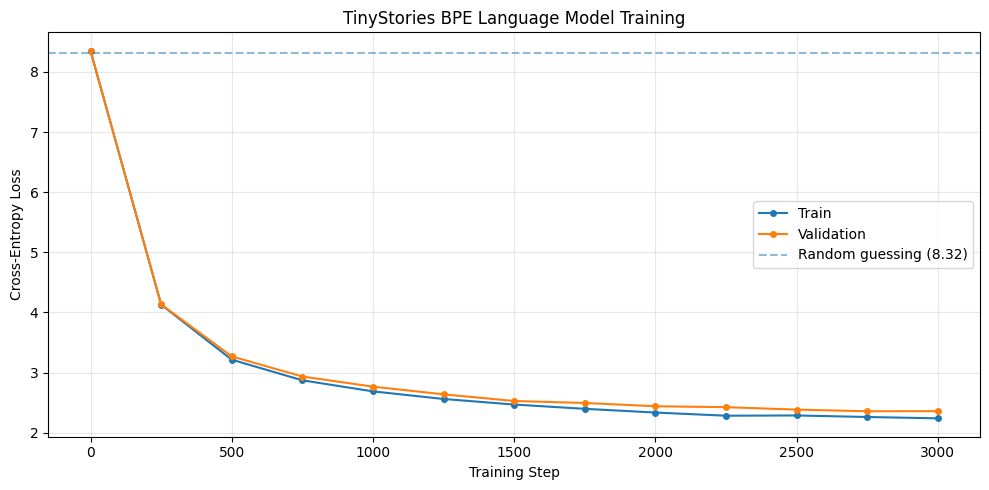

In [ ]:
# --------------------------------------------------
# Plot Training and Validation Loss
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 5))

# Training loss
ax.plot(
    step_log,
    train_losses,
    "-o",
    label="Train",
    markersize=4,
)

# Validation loss
ax.plot(
    step_log,
    val_losses,
    "-o",
    label="Validation",
    markersize=4,
)

# Random-guessing baseline
random_loss = math.log(vocab_size)

ax.axhline(
    y=random_loss,
    linestyle="--",
    alpha=0.5,
    label=f"Random guessing ({random_loss:.2f})",
)

ax.set_xlabel("Training Step")
ax.set_ylabel("Cross-Entropy Loss")

ax.set_title(
    "TinyStories BPE Language Model Training"
)

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Section 7: Generate Text! 🎭

The payoff. We feed in a seed text, predict the next character, append it, and repeat. This is **autoregressive generation** — the same process ChatGPT uses, just at character level.

In [ ]:
@torch.no_grad()
def generate(
    model,
    prompt,
    max_new_tokens=500,
    temperature=0.8,
):
    """
    Generate TinyStories text autoregressively.

    The model predicts one BPE token at a time.

    temperature:
        0.3 -> conservative / repetitive
        0.8 -> balanced
        1.0 -> normal sampling
        1.2 -> more random / creative
    """

    assert temperature > 0, "Temperature must be greater than 0."

    model.eval()

    # --------------------------------------------------
    # 1. Encode prompt into BPE token IDs
    # --------------------------------------------------

    token_ids = encode(prompt)

    tokens = torch.tensor(
        token_ids,
        dtype=torch.long,
        device=device,
    ).unsqueeze(0)

    # tokens shape:
    # [1, prompt_length]

    # --------------------------------------------------
    # 2. Autoregressive generation
    # --------------------------------------------------

    for _ in range(max_new_tokens):

        # Keep only the most recent context window
        context = tokens[
            :, -config["max_seq_len"]:]

        # Model predicts next-token distribution
        logits, _ = model(context)

        # Only need predictions for the final position
        logits = logits[:, -1, :]

        # --------------------------------------------------
        # Temperature
        # --------------------------------------------------

        logits = logits / temperature

        # Convert logits → probabilities
        probs = F.softmax(
            logits,
            dim=-1,
        )

        # --------------------------------------------------
        # Sample next BPE token
        # --------------------------------------------------

        next_token = torch.multinomial(
            probs,
            num_samples=1,
        )

        # Append generated token
        tokens = torch.cat(
            [tokens, next_token],
            dim=1,
        )

    # --------------------------------------------------
    # 3. Decode BPE tokens back to text
    # --------------------------------------------------

    generated_text = decode(
        tokens[0].tolist()
    )

    model.train()

    return generated_text

In [ ]:
# --------------------------------------------------
# Generate at Different Temperatures
# --------------------------------------------------

prompt = "Once upon a time"

print("=" * 60)
print(f"  PROMPT: {prompt!r}")
print("=" * 60)

for temp in [0.5, 0.8, 1.0, 1.2]:

    print(f"\n{'_' * 60}")
    print(f"  Temperature = {temp}")
    print(f"{'_' * 60}")

    output = generate(
        model,
        prompt,
        max_new_tokens=300,
        temperature=temp,
    )

    print(output)

  PROMPT: 'Once upon a time'

____________________________________________________________
  Temperature = 0.5
____________________________________________________________
ĠOnce Ġupon Ġa Ġtime , Ġthere Ġwas Ġa Ġlittle Ġgirl Ġnamed ĠLily . ĠShe Ġloved Ġto Ġplay Ġoutside Ġin Ġthe Ġpark Ġwith Ġher Ġfriends . ĠOne Ġday , ĠLily 's Ġmom Ġtold Ġher Ġthat Ġthey Ġwere Ġgoing Ġto Ġa Ġbig Ġpark Ġand ĠLily Ġwanted Ġto Ġplay Ġwith Ġit . Ġ Ċ Lily 's Ġfriend , ĠTimmy , Ġsaid , Ġ" Let 's Ġgo Ġplay Ġa Ġgame Ġwith Ġthe Ġother Ġkids ." Ġ Ċ Lily Ġsaid , Ġ" Let 's Ġgo Ġto Ġthe Ġpark Ġand Ġplay Ġwith Ġthe Ġball ." Ġ Ċ A s Ġthey Ġwere Ġwalking , ĠLily Ġsaw Ġa Ġboy Ġplaying Ġwith Ġa Ġball . ĠShe Ġasked Ġhim Ġif Ġhe Ġcould Ġplay Ġwith Ġit . ĠLily Ġsaid Ġyes , Ġbut Ġthe Ġboy Ġsaid Ġno . ĠLily Ġfelt Ġsad Ġand Ġdidn 't Ġknow Ġwhat Ġto Ġdo . Ġ Ċ A s Ġthey Ġwere Ġplaying , ĠLily Ġsaw Ġa Ġbig Ġdog Ġthat Ġwas Ġplaying Ġwith Ġa Ġball . ĠShe Ġasked Ġher Ġmom Ġif Ġshe Ġcould Ġplay Ġwith Ġit Ġtoo . ĠHer Ġmom Ġsaid Ġyes ,

In [ ]:
# --------------------------------------------------
# Try Different TinyStories Prompts
# --------------------------------------------------

prompts = [
    "Once upon a time",
    "The little girl",
    "A little boy",
    "One day",
    "The cat",
    "There was a little",
]

for p in prompts:

    print(f"\n{'=' * 60}")
    print(f"  PROMPT: {p!r}")
    print(f"{'=' * 60}")

    output = generate(
        model,
        p,
        max_new_tokens=200,
        temperature=0.8,
    )

    print(output)


  PROMPT: 'Once upon a time'
ĠOnce Ġupon Ġa Ġtime , Ġthere Ġwas Ġa Ġbig Ġwave . ĠThe Ġduck Ġliked Ġto Ġswim Ġand Ġplay Ġpatient . ĠBut Ġone Ġday , Ġthe Ġduck Ġsaw Ġa Ġnew Ġlake . ĠThe Ġduck Ġwanted Ġto Ġclimb Ġthe Ġpond Ġso Ġit Ġran Ġto Ġthe Ġsea . ĠHe Ġlost Ġhis Ġown Ġwater Ġand Ġstarted Ġto Ġwatch . Ċ S uddenly , Ġthe Ġbig Ġfish Ġcame Ġand Ġgot Ġvery Ġdirty . ĠThe Ġfrog Ġfound Ġhis Ġway Ġback Ġto Ġthe Ġpond Ġand Ġran Ġback Ġto Ġthe Ġpond . ĠThey Ġwere Ġhappy Ġand Ġcheered . ĠThey Ġhad Ġa Ġfun Ġday Ġat Ġthe Ġshore . Ċ <| endoftext |> Ċ O n ce Ġupon Ġa Ġtime , Ġthere Ġwas Ġa Ġlittle Ġgirl Ġnamed ĠDaisy . ĠDaisy Ġloved Ġto Ġplay Ġoutside Ġand Ġexplore Ġthe Ġworld . Ċ O ne Ġday , ĠDaisy Ġsaw Ġa Ġbeautiful Ġsight . ĠShe Ġwanted Ġto Ġexplore Ġit , Ġso Ġher Ġparents Ġdecided Ġto Ġexplore Ġthe Ġworld . ĠThey Ġwere Ġso Ġexcited Ġto Ġexplore Ġthe Ġocean . Ġ Ċ S o ĠLucy Ġand Ġher Ġfamily Ġwent Ġnear Ġthe Ġbig Ġfence . ĠThey Ġfound Ġlots Ġof Ġdifferent Ġthings Ġto Ġexplore . ĠThey Ġhad Ġall Ġki

---
# Section 8: Experiments (Try These!)

Now that you have a working model, explore:

1. **Temperature sweep:** Generate the same prompt at temperatures 0.1, 0.5, 1.0, 1.5, 2.0. What happens at extremes?
2. **Model surgery:** Print weight shapes and spot the GQA difference.
3. **Scaling question:** What would happen if you doubled `d_model`? (Think about it before trying!)

In [ ]:
# --------------------------------------------------
# Experiment 1: Temperature Sweep
# --------------------------------------------------

prompt = "Once upon a time"

print("Temperature sweep on the same TinyStories prompt:\n")

for temp in [0.1, 0.3, 0.5, 0.8, 1.0, 1.5]:

    output = generate(
        model,
        prompt,
        max_new_tokens=100,
        temperature=temp,
    )

    # Remove the original prompt from the decoded output
    generated = output[len(prompt):]

    print(f"  T={temp:.1f}: {generated[:80]}...")
    print()

Temperature sweep on the same TinyStories prompt:

  T=0.1: time , Ġthere Ġwas Ġa Ġlittle Ġgirl Ġnamed ĠLily . ĠShe Ġloved Ġto Ġplay Ġoutsid...

  T=0.3: time , Ġthere Ġwas Ġa Ġlittle Ġgirl Ġnamed ĠLily . ĠShe Ġloved Ġto Ġplay Ġoutsid...

  T=0.5: time , Ġthere Ġwas Ġa Ġlittle Ġgirl Ġnamed ĠLily . ĠShe Ġloved Ġto Ġplay Ġoutsid...

  T=0.8: time , Ġthere Ġwas Ġa Ġseal Ġwho Ġlived Ġin Ġa Ġsmall Ġboat . ĠHe Ġliked Ġto Ġpl...

  T=1.0: time Ġthere Ġwas Ġa Ġlittle Ġboy Ġnamed ĠJack . ĠOne Ġday , ĠJack Ġfound Ġa Ġbro...

  T=1.5: time , Ġthere Ġwas Ġa Ġman Ġcoming Ġinto Ġget Ġdeep ling . ĠHe Ġlived Ġin Ġthe Ġ...



In [ ]:
# --------------------------------------------------
# Experiment 2: See GQA in the Weight Shapes
# --------------------------------------------------

print("GQA in the weights:\n")

layer = model.layers[0].attention

q_shape = layer.q_proj.weight.shape
k_shape = layer.k_proj.weight.shape
v_shape = layer.v_proj.weight.shape

print(f"  Q projection: {q_shape}")
print(f"  K projection: {k_shape}")
print(f"  V projection: {v_shape}")

# Number of output dimensions
q_dim = q_shape[0]
k_dim = k_shape[0]
v_dim = v_shape[0]

print("\n  Configuration:")
print(f"    Query heads: {config['n_heads']}")
print(f"    KV heads:    {config['n_kv_heads']}")
print(f"    Head dim:    {config['d_model'] // config['n_heads']}")

print(
    f"\n  Q has {q_dim // k_dim}x more output dimensions "
    f"than K and V."
)

print(
    f"  Each KV head is shared by "
    f"{config['n_heads'] // config['n_kv_heads']} "
    f"Query heads."
)

print(
    f"  -> KV cache is approximately "
    f"{config['n_heads'] // config['n_kv_heads']}x "
    f"smaller than standard MHA."
)

GQA in the weights:

  Q projection: torch.Size([256, 256])
  K projection: torch.Size([64, 256])
  V projection: torch.Size([64, 256])

  Configuration:
    Query heads: 8
    KV heads:    2
    Head dim:    32

  Q has 4x more output dimensions than K and V.
  Each KV head is shared by 4 Query heads.
  -> KV cache is approximately 4x smaller than standard MHA.


In [ ]:
sample = "Once upon a time, there was a little girl."

encoding = tokenizer.encode(sample)

print("Tokens:")
print(encoding.tokens)

print("\nIDs:")
print(encoding.ids)

print("\nDecoded:")
print(tokenizer.decode(encoding.ids))

Tokens:
['ĠOnce', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġthere', 'Ġwas', 'Ġa', 'Ġlittle', 'Ġgirl', '.']

IDs:
[287, 299, 108, 254, 13, 258, 132, 108, 257, 305, 15]

Decoded:
ĠOnce Ġupon Ġa Ġtime , Ġthere Ġwas Ġa Ġlittle Ġgirl .
